# Wyniki eksperymentow

Wszystkie wykresy z E1 i E2. Dane wczytywane z `experiments/analysis/*.csv`, ktore powstaja przy
`python run.py E1` i `python run.py E2`. Caly kod rysujacy jest w tym notatniku.

Eterna wszedzie ograniczona do **<= 50 nt** (11 zagadek po odsianiu redundancji).

**Trzy miary:**

| miara | co znaczy | uzywa RNAfolda |
|---|---|---|
| `rozwiazane` | czy nasza sekwencja ZWIJA SIE w zadana strukture | tak |
| `odzysk` | ulamek pozycji trafionych wzgledem prawdziwej sekwencji | nie |
| `dE/nt` | o ile stabilizujemy cel lepiej niz prawdziwa sekwencja | nie |

`rozwiazane` **nie porownuje sekwencji z odpowiedzia**. Sekwencja calkiem inna od wzorcowej moze
rozwiazac zagadke, jesli tylko zwija sie poprawnie.


In [1]:
import sys
from collections import Counter
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from src.dataset import motyw_pozycji, parse_pairs, BASES, MOTYWY
from src.prepare import wczytaj, wczytaj_eterna
from src.split import wczytaj_split

# --- wspolny styl wykresow -------------------------------------------------
# Paleta sprawdzona pod katem separacji przy protanopii i deuteranopii oraz kontrastu wobec tla.
C1, C2, C3, C4 = "#0E6B60", "#9C5518", "#6B4E9C", "#8A9896"
INK, INK2, SIATKA = "#14201E", "#4C5C59", "#DCE4E2"
plt.rcParams["figure.dpi"] = 120


def styl(ax, tytul="", ylab="", xlab=""):
    """Wspolne ustawienia osi: bez ramki, siatka pozioma, stonowane opisy."""
    ax.set_facecolor("none")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(SIATKA)
    ax.tick_params(colors=INK2, labelsize=9)
    ax.grid(axis="y", color=SIATKA, lw=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    if tytul:
        ax.set_title(tytul, color=INK, fontsize=11, loc="left", pad=12)
    ax.set_ylabel(ylab, color=INK2, fontsize=9)
    ax.set_xlabel(xlab, color=INK2, fontsize=9)


def sklad_motywy(structs, seqs):
    """Zliczenia A/C/G/U w kazdym motywie strukturalnym, po wszystkich sekwencjach."""
    c = {m: Counter() for m in MOTYWY}
    for st, sq in zip(structs, seqs):
        for m, b in zip(motyw_pozycji(st), sq):
            if m:
                c[m][b] += 1
    return c


def typy_par(structs, seqs):
    """Zliczenia typow par G:C / A:U / G:U."""
    t = Counter()
    grupy = {"G:C": {"GC", "CG"}, "A:U": {"AU", "UA"}, "G:U": {"GU", "UG"}}
    for st, sq in zip(structs, seqs):
        for i, j in parse_pairs(st):
            p = sq[i] + sq[j]
            for k, g in grupy.items():
                if p in g:
                    t[k] += 1
    return t


In [2]:
PLIKI = {
    "baseline losowy": "baseline_test.csv",
    "E1  sklad 1,7":   "e1_test.csv",
    "E2  sklad 0":     "e2_w0_test.csv",
    "E2  sklad 40":    "e2_w40_test.csv",
}
ANALIZA = Path.cwd().parent / "experiments" / "analysis"

kawalki = []
for lab, p in PLIKI.items():
    f = ANALIZA / p
    if f.exists():
        x = pd.read_csv(f)
        x["etykieta"] = lab
        kawalki.append(x)
    else:
        print(f"brak {p} — uruchom odpowiedni eksperyment")
d = pd.concat(kawalki, ignore_index=True)
d["% rozwiazanych"] = (100 * d.rozwiazane / d.n).round(1)
d[["etykieta", "zbior", "dlugosc", "n", "rozwiazane", "% rozwiazanych", "odzysk", "dE_nt"]]

,etykieta,zbior,dlugosc,n,rozwiazane,% rozwiazanych,odzysk,dE_nt
0,baseline losowy,test,0-50,14,2,14.3,0.252607,0.011283
1,baseline losowy,test,51-100,451,3,0.7,0.261017,-0.046781
2,baseline losowy,test,101-200,274,0,0.0,0.264171,-0.018110
3,baseline losowy,eterna<=50,0-50,11,2,18.2,0.310119,0.142334
4,"E1 sklad 1,7",test,0-50,14,8,57.1,0.276988,-0.236230
5,"E1 sklad 1,7",test,51-100,451,187,41.5,0.301238,-0.223787
6,"E1 sklad 1,7",test,101-200,274,33,12.0,0.307384,-0.168868
7,"E1 sklad 1,7",eterna<=50,0-50,11,7,63.6,0.517648,-0.098609
8,E2 sklad 0,test,0-50,14,10,71.4,0.293798,-0.238741
9,E2 sklad 0,test,51-100,451,190,42.1,0.298370,-0.232260


## 1. Ile struktur rozwiazanych

Baseline to sekwencja losowana z naturalnych czestosci, z zachowaniem komplementarnosci par. Mierzy,
ile da sie ugrac SAMA komplementarnoscia, bez zadnego uczenia — i jest punktem odniesienia dla
pytania, czy model faktycznie czegos sie nauczyl.

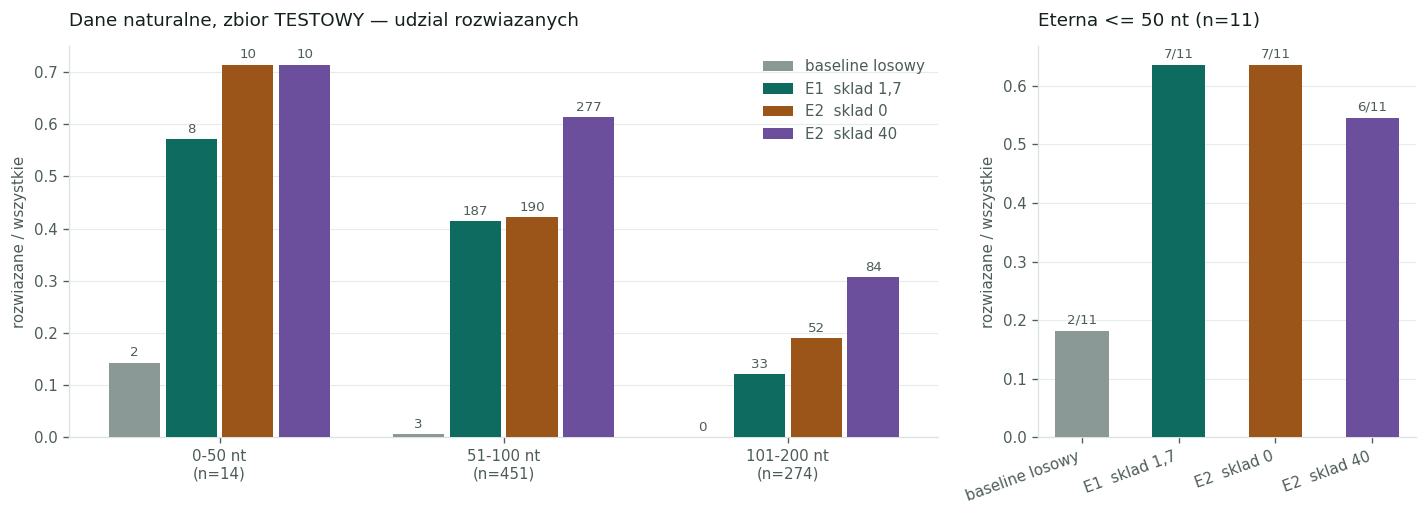

In [3]:
nat = d[d.zbior == "test"]
et = d[d.zbior.str.startswith("eterna")]
kub = list(dict.fromkeys(nat.dlugosc))
lab = list(dict.fromkeys(d.etykieta))
kolory_m = dict(zip(lab, [C4, C1, C2, C3][:len(lab)]))

fig, axs = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw={"width_ratios": [2.3, 1]})
x = np.arange(len(kub))
w = 0.8 / len(lab)
for k, l in enumerate(lab):
    v, n = [], []
    for kk in kub:
        r = nat[(nat.etykieta == l) & (nat.dlugosc == kk)]
        v.append(float(r.rozwiazane.iloc[0] / r.n.iloc[0]) if len(r) else 0.0)
        n.append(int(r.rozwiazane.iloc[0]) if len(r) else 0)
    b = axs[0].bar(x + (k - (len(lab) - 1) / 2) * w, v, w * 0.9,
                   color=kolory_m[l], label=l, zorder=3)
    for r, nn in zip(b, n):
        axs[0].text(r.get_x() + r.get_width() / 2, r.get_height() + 0.012, str(nn),
                    ha="center", fontsize=8, color=INK2)
axs[0].set_xticks(x)
axs[0].set_xticklabels([f"{kk} nt\n(n={int(nat[nat.dlugosc == kk].n.iloc[0])})" for kk in kub],
                       fontsize=9)
styl(axs[0], "Dane naturalne, zbior TESTOWY — udzial rozwiazanych", "rozwiazane / wszystkie")
axs[0].legend(frameon=False, fontsize=9, labelcolor=INK2)

for k, l in enumerate(lab):
    r = et[et.etykieta == l]
    if not len(r):
        continue
    v = float(r.rozwiazane.iloc[0] / r.n.iloc[0])
    axs[1].bar([k], [v], 0.55, color=kolory_m[l], zorder=3)
    axs[1].text(k, v + 0.012, f"{int(r.rozwiazane.iloc[0])}/{int(r.n.iloc[0])}",
                ha="center", fontsize=8, color=INK2)
axs[1].set_xticks(range(len(lab)))
axs[1].set_xticklabels(lab, fontsize=7, rotation=20, ha="right")
styl(axs[1], f"Eterna <= 50 nt (n={int(et.n.iloc[0])})", "rozwiazane / wszystkie")
fig.tight_layout()

## 2. Energia — jedyna miara bez zwijania

Ujemna wartosc znaczy, ze nasza sekwencja stabilizuje zadana strukture LEPIEJ niz prawdziwa sekwencja
z bazy. Warto zestawic z poprzednim wykresem: energia bywa dobra takze tam, gdzie liczba rozwiazanych
spada.

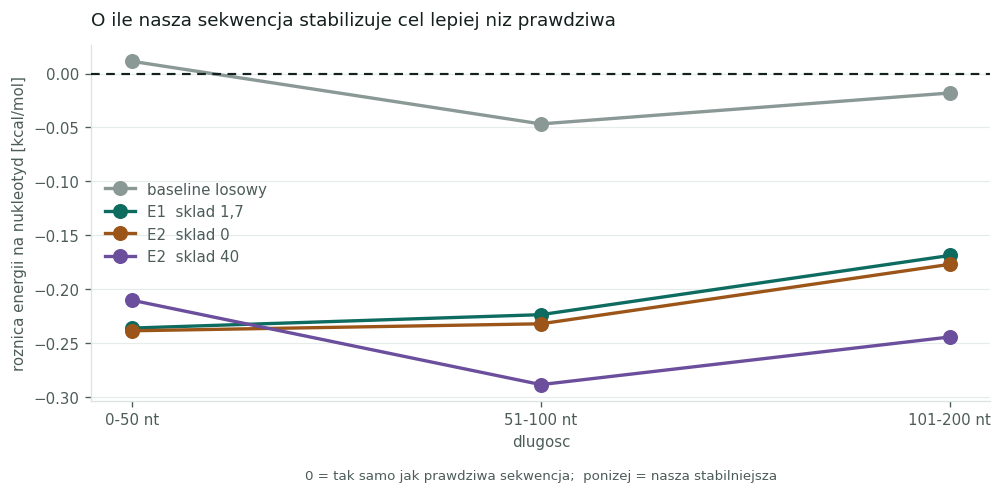

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4.3))
for l in lab:
    v = []
    for kk in kub:
        r = nat[(nat.etykieta == l) & (nat.dlugosc == kk)]
        v.append(float(r.dE_nt.iloc[0]) if len(r) else np.nan)
    ax.plot(range(len(kub)), v, "-o", color=kolory_m[l], lw=2, ms=8, label=l, zorder=3)
ax.axhline(0, color=INK, lw=1.3, ls=(0, (4, 3)), zorder=4)
ax.set_xticks(range(len(kub)))
ax.set_xticklabels([f"{kk} nt" for kk in kub], fontsize=9)
styl(ax, "O ile nasza sekwencja stabilizuje cel lepiej niz prawdziwa",
     "roznica energii na nukleotyd [kcal/mol]", "dlugosc")
ax.legend(frameon=False, fontsize=9, labelcolor=INK2)
ax.text(0.5, -0.22, "0 = tak samo jak prawdziwa sekwencja;  ponizej = nasza stabilniejsza",
        transform=ax.transAxes, fontsize=8, color=INK2, ha="center")
fig.tight_layout()

## 3. Co model produkuje — generowanie

Ponizsze komorki laduja checkpointy i generuja sekwencje dla zbioru testowego ORAZ dla Eterny.
Wymaga GPU.

In [5]:
import torch
from src.evaluate import wczytaj_model, generuj, eterna as eterna_zbior

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baza = wczytaj()
idx = wczytaj_split("rodzinowy")["test"]
S = baza.secondary_structure.iloc[idx].tolist()
Q = baza.sequence.iloc[idx].tolist()
ET, ER = eterna_zbior(50)          # struktury i rozwiazania graczy, <= 50 nt

MODELE = {"E1  sklad 1,7": "checkpoints/e1_kary.pt",
          "E2  sklad 0":   "checkpoints/e2_sklad0.pt",
          "E2  sklad 40":  "checkpoints/e2_sklad40.pt"}
gen, gen_et = {}, {}
for l, ck in MODELE.items():
    m = wczytaj_model(ck, dev)
    gen[l] = generuj(m, S, dev)
    gen_et[l] = generuj(m, ET, dev)
    del m
    torch.cuda.empty_cache()
print(f"test naturalny: {len(S)} struktur | Eterna <= 50 nt: {len(ET)} zagadek")

c:\Users\janle\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


test naturalny: 739 struktur | Eterna <= 50 nt: 11 zagadek


## 4. Typy par — wobec sekwencji naturalnych i wobec Eterny

Dwa panele, bo to sa dwa rozne pytania. Po lewej: czy model przypomina **biologie**. Po prawej: czy
przypomina **ludzkie projekty**, ktore same odbiegaja od skladu naturalnego, bo powstaly pod
jednoznaczne zwijanie.

Prawy panel opiera sie na 11 zagadkach — szumny, traktowac ostroznie.

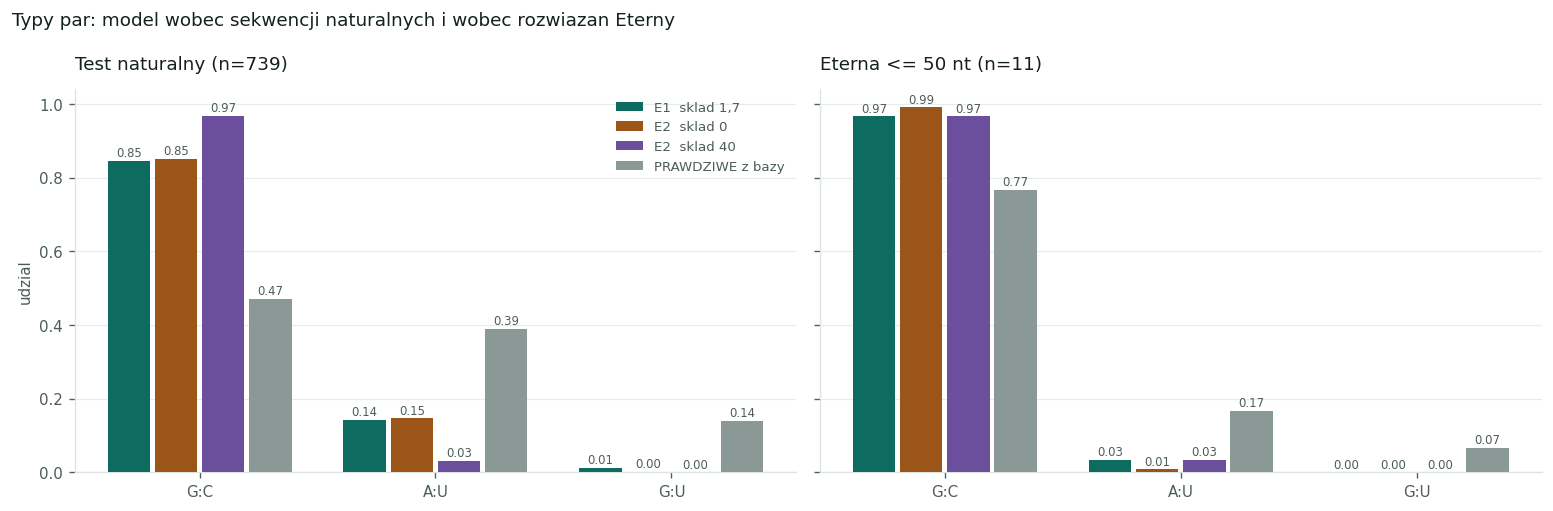

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.3), sharey=True)
x = np.arange(3)

for ax, (structs, gener, ref, ref_lab, tyt) in zip(axs, [
        (S, gen, Q, "PRAWDZIWE z bazy", f"Test naturalny (n={len(S)})"),
        (ET, gen_et, ER, "rozwiazania Eterny", f"Eterna <= 50 nt (n={len(ET)})")]):
    zrodla_p = [(l, g[structs is ET]) if False else (l, g) for l, g in gener.items()]
    zrodla_p = list(gener.items()) + [(ref_lab, ref)]
    w = 0.8 / len(zrodla_p)
    for k, (l, g) in enumerate(zrodla_p):
        t = typy_par(structs, g)
        tot = sum(t.values()) or 1
        v = [t[kk] / tot for kk in ("G:C", "A:U", "G:U")]
        b = ax.bar(x + (k - (len(zrodla_p) - 1) / 2) * w, v, w * 0.9,
                   color=[C1, C2, C3, C4][k], label=l, zorder=3)
        for r, vv in zip(b, v):
            ax.text(r.get_x() + r.get_width() / 2, vv + 0.012, f"{vv:.2f}",
                    ha="center", fontsize=7, color=INK2)
    ax.set_xticks(x)
    ax.set_xticklabels(["G:C", "A:U", "G:U"], fontsize=10)
    styl(ax, tyt, "udzial" if ax is axs[0] else "")
axs[0].legend(frameon=False, fontsize=8, labelcolor=INK2)
fig.suptitle("Typy par: model wobec sekwencji naturalnych i wobec rozwiazan Eterny",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## 5. Sklad wg motywu — wobec sekwencji naturalnych

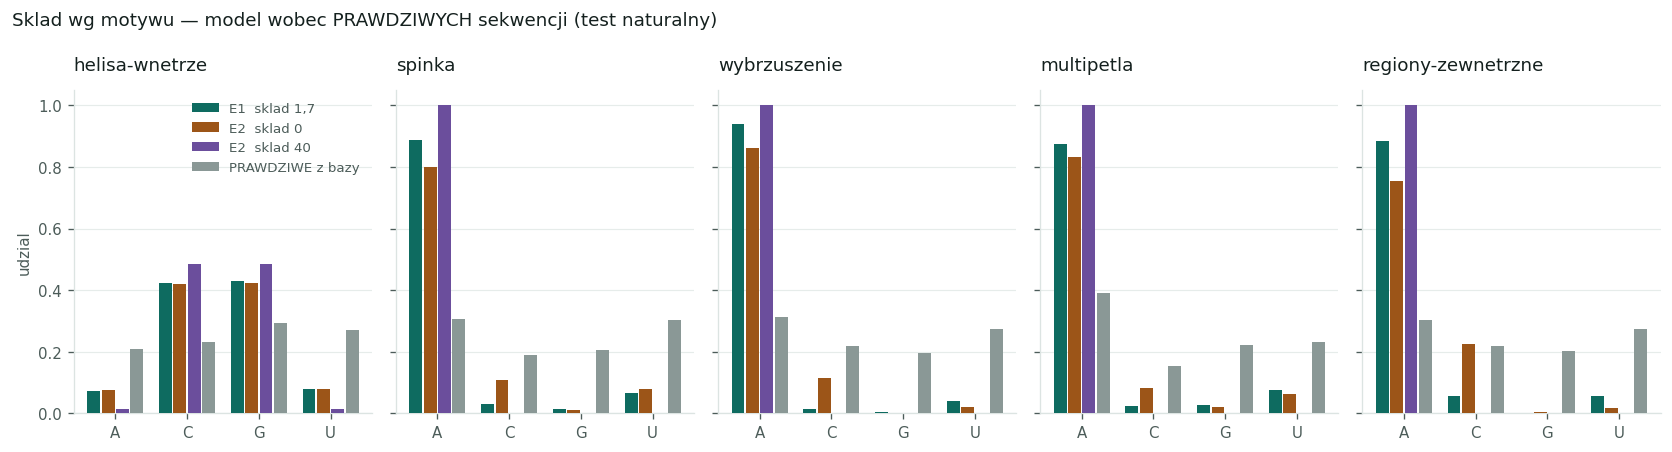

In [7]:
pokaz = ["helisa-wnetrze", "spinka", "wybrzuszenie", "multipetla", "regiony-zewnetrzne"]
zrodla_n = list(gen.items()) + [("PRAWDZIWE z bazy", Q)]

fig, axs = plt.subplots(1, len(pokaz), figsize=(14, 3.8), sharey=True)
x = np.arange(4)
w = 0.8 / len(zrodla_n)
for ax, m in zip(axs, pokaz):
    for k, (l, g) in enumerate(zrodla_n):
        c = sklad_motywy(S, g)[m]
        t = sum(c.values()) or 1
        ax.bar(x + (k - (len(zrodla_n) - 1) / 2) * w, [c[b] / t for b in BASES], w * 0.9,
               color=[C1, C2, C3, C4][k], label=l if m == pokaz[0] else None, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(BASES, fontsize=9)
    styl(ax, m, "udzial" if m == pokaz[0] else "")
axs[0].legend(frameon=False, fontsize=8, labelcolor=INK2)
fig.suptitle("Sklad wg motywu — model wobec PRAWDZIWYCH sekwencji (test naturalny)",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## 6. Sklad wg motywu — wobec rozwiazan Eterny

To samo, ale odniesieniem sa ludzkie projekty, nie biologia. Tylko 11 zagadek, wiec niektore motywy
moga miec bardzo malo pozycji — liczby pod tytulami mowia ile.

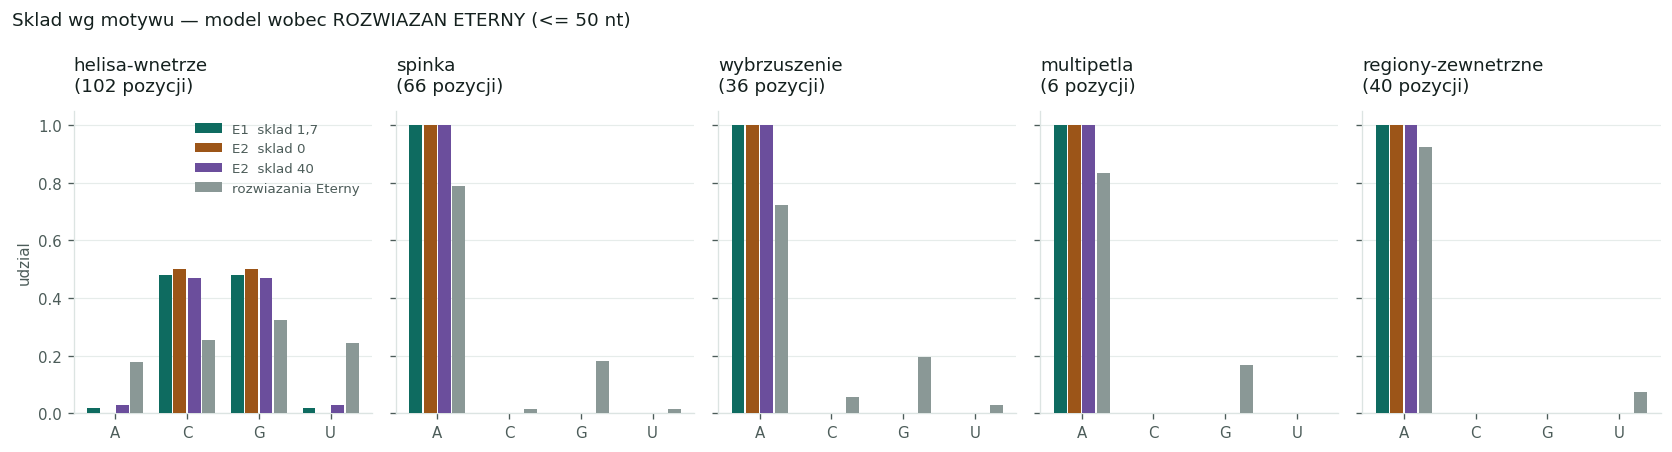

In [8]:
zrodla_e = list(gen_et.items()) + [("rozwiazania Eterny", ER)]

fig, axs = plt.subplots(1, len(pokaz), figsize=(14, 3.8), sharey=True)
w = 0.8 / len(zrodla_e)
for ax, m in zip(axs, pokaz):
    n_poz = sum(sklad_motywy(ET, ER)[m].values())
    for k, (l, g) in enumerate(zrodla_e):
        c = sklad_motywy(ET, g)[m]
        t = sum(c.values()) or 1
        ax.bar(x + (k - (len(zrodla_e) - 1) / 2) * w, [c[b] / t for b in BASES], w * 0.9,
               color=[C1, C2, C3, C4][k], label=l if m == pokaz[0] else None, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(BASES, fontsize=9)
    styl(ax, f"{m}\n({n_poz} pozycji)", "udzial" if m == pokaz[0] else "")
axs[0].legend(frameon=False, fontsize=8, labelcolor=INK2)
fig.suptitle("Sklad wg motywu — model wobec ROZWIAZAN ETERNY (<= 50 nt)",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()